In [10]:
# Step 1: Imports
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split


In [11]:
# Step 2: Load preprocessed data
X = np.load("savedPackages/padded_sequences.npy")
y = np.load("savedPackages/labels.npy")


In [12]:
# Recreate and fit tokenizer (same way you did before saving padded_sequences.npy)
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer

# Load tokenizer if you saved it before
with open('savedPackages/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

# If you didn’t save it before, you must fit it again on the original cleaned text data
# tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
# tokenizer.fit_on_texts(cleaned_texts)  # <-- where cleaned_texts is your original cleaned tweet list


In [13]:
# Step 3: Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [14]:
import numpy as np

embedding_dim = 100  # must match your GloVe vector dimension
vocab_size = len(tokenizer.word_index) + 1  # +1 for padding token
max_len = 100 

# Load GloVe embeddings
embeddings_index = {}
with open('embeddings/glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

# Create embedding matrix for your vocab
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

# Define model with pretrained embeddings
model = Sequential([
    Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=True),
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(3, activation='softmax')
])



D:\SentimentAnalyzer_Project\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [17]:
# Step 5: Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [18]:
# Step 6: Add EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)


In [19]:
# Step 7: Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=512,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


Epoch 1/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 228s 272ms/step - accuracy: 0.8158 - loss: 0.6291 - val_accuracy: 0.9434 - val_loss: 0.2330
Epoch 2/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 215s 262ms/step - accuracy: 0.9455 - loss: 0.2225 - val_accuracy: 0.9367 - val_loss: 0.2279
Epoch 3/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 218s 266ms/step - accuracy: 0.9541 - loss: 0.1862 - val_accuracy: 0.9537 - val_loss: 0.1817
Epoch 4/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 299s 311ms/step - accuracy: 0.9566 - loss: 0.1747 - val_accuracy: 0.9487 - val_loss: 0.1900
Epoch 5/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 266s 324ms/step - accuracy: 0.9598 - loss: 0.1642 - val_accuracy: 0.9538 - val_loss: 0.1787
Epoch 6/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 257s 313ms/step - accuracy: 0.9622 - loss: 0.1587 - val_accuracy: 0.9538 - val_loss: 0.1817
Epoch 7/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 278s 332ms/step - accuracy: 0.9642 - loss: 0.1501 - val_accuracy: 0.9537 - val_loss: 0.1838


In [72]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 100)       │    23,222,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,533,963 (280.51 MB)

 Trainable params: 24,511,235 (93.50 MB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 49,022,472 (187.01 MB)

FileNotFoundError: [Errno 2] No such file or directory: 'plots/accuracy_plot.png'

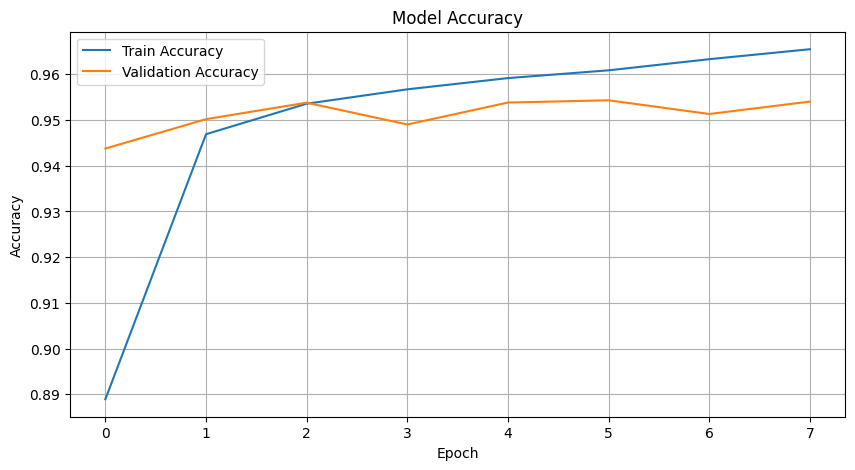

In [73]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig("plots/accuracy_plot.png")
plt.show()

# Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig("plots/loss_plot.png")
plt.show()


In [74]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


3282/3282 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9538 - loss: 0.1822
Test Accuracy: 0.9543
Test Loss: 0.1822


3282/3282 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step
              precision    recall  f1-score   support

     Class 0       0.96      0.95      0.95     35000
     Class 1       0.97      0.95      0.96     35000
     Class 2       0.94      0.97      0.95     35000

    accuracy                           0.95    105000
   macro avg       0.95      0.95      0.95    105000
weighted avg       0.95      0.95      0.95    105000



FileNotFoundError: [Errno 2] No such file or directory: 'plots/confusion_matrix.png'

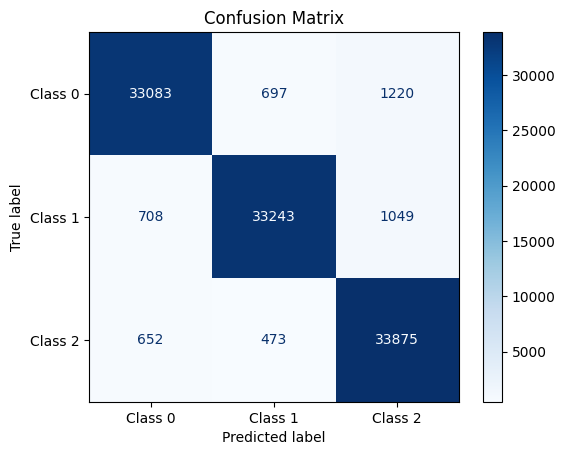

In [75]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred = np.argmax(model.predict(X_test), axis=-1)

# Classification Report
report = classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1', 'Class 2'])
print(report)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1', 'Class 2'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.savefig("plots/confusion_matrix.png")
plt.show()


In [76]:
model.save("ann_model_final_modal_last.keras")


In [77]:
# Optionally save history for future plotting or loading
import pickle
with open("savedPackages/training_history_for_ann_final.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [47]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive", "Neutral"]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.96      0.95     35000
    Positive       0.97      0.95      0.96     35000
     Neutral       0.95      0.96      0.95     35000

    accuracy                           0.95    105000
   macro avg       0.95      0.95      0.95    105000
weighted avg       0.95      0.95      0.95    105000

Confusion Matrix:
[[33624   609   767]
 [  977 33144   879]
 [ 1048   497 33455]]


In [48]:
model.save("savedPackages/ann_model_glove_trainable.keras")


In [44]:
import pickle
with open("savedPackages/ann_tokenizer_glove_trainable.pkl", "wb") as f:
    pickle.dump(tokenizer, f)


In [37]:
import pickle
from tensorflow.keras.models import load_model

# Load tokenizer
with open("savedPackages/ann_tokenizer_glove_trainable.pkl", "rb") as f:
    tokenizer = pickle.load(f)

# Load ANN model
model = load_model("savedPackages/ann_model_glove_trainable.keras")


EOFError: Ran out of input

In [2]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


In [35]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Parameters (same as training)
max_len = 100

# Your custom sentence
custom_text = "I am not okay with this"

# Clean it
cleaned = clean_text(custom_text)

# Tokenize and pad
sequence = tokenizer.texts_to_sequences([cleaned])
padded = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')


In [36]:
import numpy as np

# Predict
prediction = model.predict(padded)
predicted_label = np.argmax(prediction)

# Map label
label_map = {0: "Negative", 1: "Positive", 2: "Neutral"}
print(f"Predicted Sentiment: {label_map[predicted_label]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Predicted Sentiment: Negative


In [56]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np

y_pred = np.argmax(model.predict(X_test), axis=1)

# Get misclassified indices
misclassified_idx = np.where(y_pred != y_test)[0]

# Export a sample of errors
sample_errors = pd.DataFrame({
    'True': y_test[misclassified_idx],
    'Pred': y_pred[misclassified_idx]
})
sample_errors.to_csv("ann_misclassified.csv", index=False)


3282/3282 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step


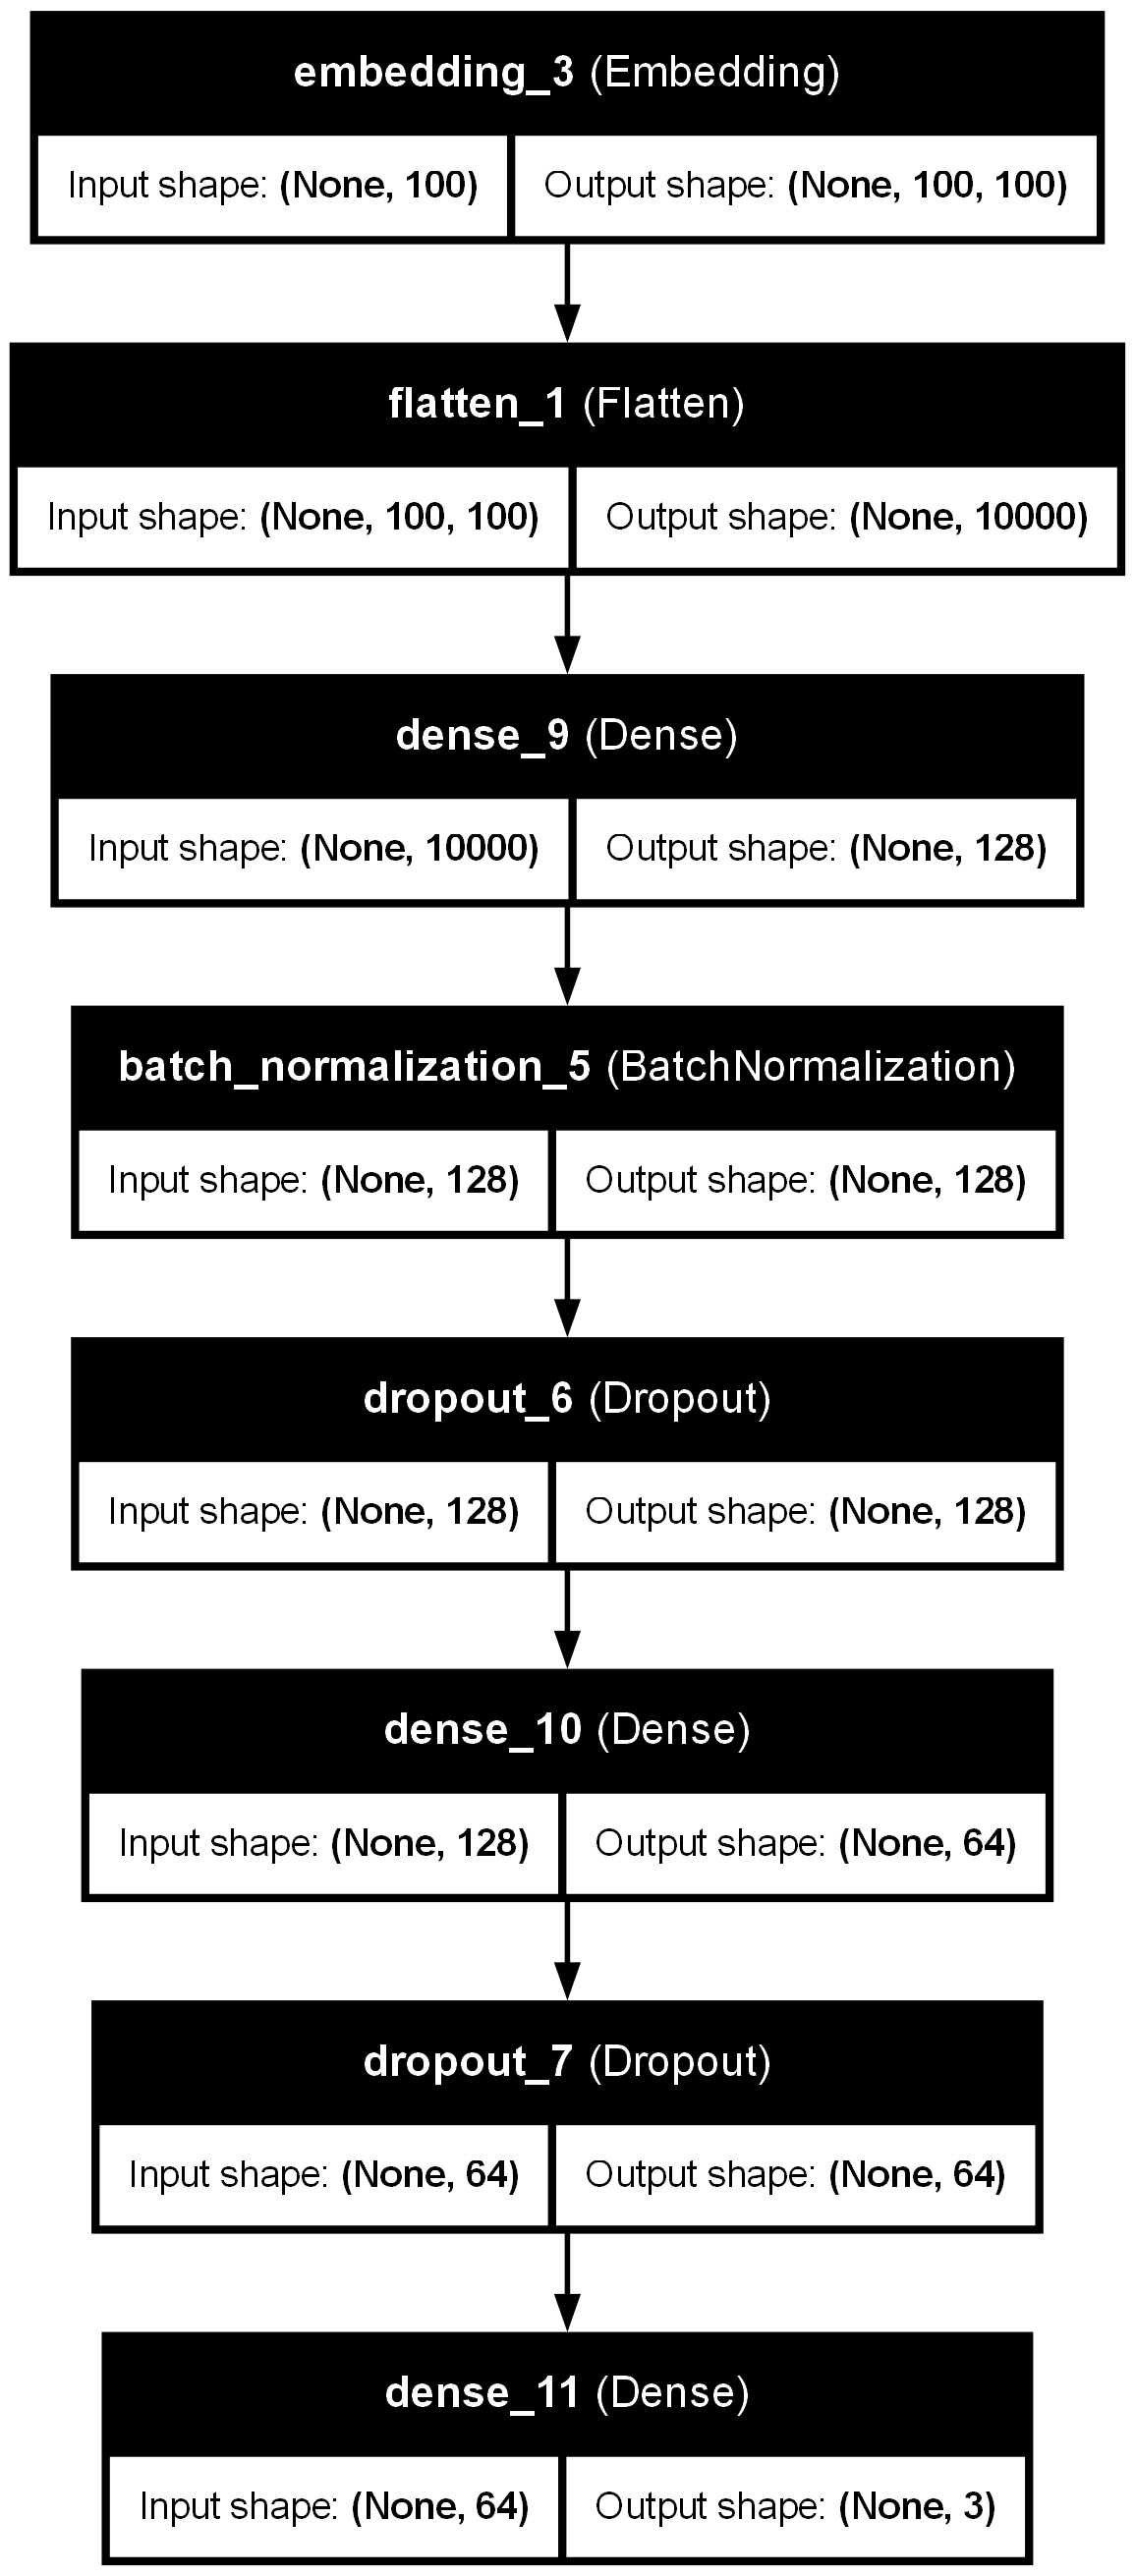

In [1]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import plot_model

# Load the saved model
model = load_model("savedPackages/ann_model_glove_trainable.keras")

# Print full architecture summary
plot_model(model, to_file="ann_model_image.png", show_shapes=True, show_layer_names=True)